In [1]:
# =========================
# Cell 1 — Parameters (EDIT HERE)
# =========================
signal_csv_path = "signals.csv"  # 本地信号CSV路径（需列：date, signal）
start = "2010-01-06"
end   = "2025-08-27"

initial_cash    = 100_000.0
sell_threshold  = 2.5    # 做空触发：signal >= threshold 且 ratio > SMA
sma_length      = 30     # VIX/VIX3M 比值的SMA窗口
warmup_days_min = 60     # 预热交易日缓冲（在SMA可用的基础上再加buffer）


In [2]:
# =========================
# Cell 2 — Imports & Settings
# =========================
from __future__ import annotations

import math
import warnings
from typing import Tuple

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)


In [3]:
# =========================
# Cell 3 — Data Utilities
# =========================
def download_yahoo(symbol: str, start_date: str, end_date: str) -> pd.DataFrame:
    """Download OHLCV data from Yahoo and standardize index/columns."""
    df = yf.download(symbol, start=start_date, end=end_date, auto_adjust=False, progress=False)
    if df is None or df.empty:
        raise RuntimeError(f"Yahoo returned empty data for {symbol}")
    df = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].copy()
    df.index = pd.to_datetime(df.index).tz_localize(None)
    return df


def load_local_signal(path: str) -> pd.Series:
    """Load local CSV of custom signal with columns: date, signal; returns Series indexed by date."""
    s = pd.read_csv(path)
    s.columns = [c.strip().lower() for c in s.columns]
    if 'date' not in s.columns or 'signal' not in s.columns:
        raise ValueError("Signal CSV must contain columns: 'date' and 'signal'")
    s['date'] = pd.to_datetime(s['date']).dt.tz_localize(None)
    s = s.sort_values('date')
    return s.set_index('date')['signal'].astype(float)


def compute_vix_ratio(start_date: str, end_date: str, align_index: pd.DatetimeIndex | None = None) -> pd.DataFrame:
    """
    Compute VIX / VIX3M ratio from Yahoo closes.
    - 强制唯一列名，防止重名
    - 若提供 align_index，则对齐到该日历并 ffill
    """
    vix = download_yahoo("^VIX", start_date, end_date)[['Close']].copy()
    v3m = download_yahoo("^VIX3M", start_date, end_date)[['Close']].copy()

    if vix.empty or v3m.empty:
        raise RuntimeError("VIX or VIX3M is empty — check date range/network.")

    # 先统一命名，避免重名
    vix.columns = ['VIX_Close']
    v3m.columns = ['VIX3M_Close']

    # 用 join（inner）先在各自日历上对齐
    out = vix.join(v3m, how='inner')

    # 可选：对齐到目标（QQQ）交易日并前向填充
    if align_index is not None:
        out = out.reindex(align_index).ffill()

    # —— 安全获取“单列 Series”，即使出现重名也只取第一列 —— 
    def _as_series(df: pd.DataFrame, col: str) -> pd.Series:
        obj = df[col]
        if isinstance(obj, pd.DataFrame):
            # 若意外出现同名多列，取第一列并告警（也可 assert 防止继续）
            obj = obj.iloc[:, 0]
        return obj.astype(float)

    s_vix = _as_series(out, 'VIX_Close')
    s_v3m = _as_series(out, 'VIX3M_Close')

    if s_vix.isna().all() or s_v3m.isna().all():
        raise RuntimeError("VIX ratio frame empty after alignment; check symbols or align_index.")

    out = pd.DataFrame({'VIX_Close': s_vix, 'VIX3M_Close': s_v3m})
    out['ratio'] = out['VIX_Close'] / out['VIX3M_Close']
    return out



def rolling_sma(x: pd.Series, n: int) -> pd.Series:
    return x.rolling(n, min_periods=n).mean()

def build_daily_frame(start_date: str, end_date: str, signal_path: str, sma_len: int, warmup_days: int) -> pd.DataFrame:
    qqq  = download_yahoo("QQQ", start_date, end_date)
    if qqq.empty:
        raise RuntimeError("QQQ data is empty; check date range/network.")
    sig  = load_local_signal(signal_path)

    # 关键：对齐到 QQQ 的交易日
    vixr = compute_vix_ratio(start_date, end_date, align_index=qqq.index)

    df = pd.DataFrame(index=qqq.index.copy())
    df['Open']   = qqq['Open']
    df['Close']  = qqq['Close']
    df['signal'] = sig.reindex(df.index)

    df = df.join(vixr[['ratio']], how='left')
    df['ratio_sma'] = df['ratio'].rolling(sma_len, min_periods=sma_len).mean()

    df['usable'] = df['ratio_sma'].notna()
    if warmup_days > 0 and len(df) > warmup_days:
        cutoff = df.index[warmup_days]
        df.loc[:cutoff, 'usable'] = False
    return df



In [4]:
# =========================
# Cell 4 — Strategy Simulation (Open → Open)
# =========================
def simulate_open_to_open(df: pd.DataFrame, initial_cash: float, sell_th: float) -> pd.DataFrame:
    """
    修正版：plan 决定“次日开盘”的动作；若 plan=='hold'，次日沿用今日持仓，不会变成 0。
    - 当日收盘做决策 -> 次日开盘生效
    - baseline：第一个 usable 日安排 next-day LONG
    - side ∈ {-1, 0, +1}，持仓在 plan=='hold' 时**延续**
    """
    out = df.copy()
    n = len(out)
    if n < 3:
        raise RuntimeError("Not enough rows to simulate.")

    # 1) 当日收盘得到“计划”
    cond_short = (out['signal'] >= sell_th) & (out['ratio'] > out['ratio_sma']) & out['usable']
    cond_long  = (out['signal'] < 0.0)      & (out['ratio'] < out['ratio_sma']) & out['usable']
    plan = np.where(cond_short, 'short', np.where(cond_long, 'long', 'hold'))

    # baseline：第一个 usable 日安排“次日”开多
    if out['usable'].any():
        i0 = int(np.argmax(out['usable'].values))
        if i0 < n-1:
            plan[i0] = 'long'

    # 2) 由 plan 生成“次日的” side（状态机：hold 时延续）
    side = np.zeros(n, dtype=int)  # side[t] 是区间 [t_open -> t+1_open) 的持仓
    for t in range(1, n):
        act = plan[t-1]  # t-1 日收盘决定 t 日开盘的动作
        if act == 'long':
            side[t] = +1
        elif act == 'short':
            side[t] = -1
        else:  # 'hold' -> 延续昨天持仓
            side[t] = side[t-1]
    # day 0 开盘之前没有持仓：side[0]=0 保持不变

    # 3) 开盘到开盘收益
    o = out['Open'].values.astype(float)
    ret_oo = np.zeros(n, dtype=float)
    ret_oo[:-1] = o[1:] / o[:-1] - 1.0
    ret_oo[-1] = 0.0  # 最后一天没有下一开盘

    port_ret = side * ret_oo

    # 4) 权益曲线
    equity = np.empty(n, dtype=float)
    equity[0] = initial_cash
    for i in range(1, n):
        equity[i] = equity[i-1] * (1.0 + port_ret[i-1])

    out['side']     = side
    out['ret_oo']   = ret_oo
    out['port_ret'] = port_ret
    out['equity']   = equity
    return out



In [5]:
# =========================
# Cell 5 — Per-Trade Table
# =========================
def build_trades_table(sim: pd.DataFrame) -> pd.DataFrame:
    """
    Each trade runs from entry open (when side changes) to exit open (next change).
    Compute per-trade gross return and holding period (trading & calendar days).
    """
    idx = sim.index
    side = sim['side'].to_numpy()
    n = len(sim)

    # where side changes at open
    changes = np.where(np.diff(side, prepend=0) != 0)[0]

    trades = []
    for k, i in enumerate(changes):
        if i == 0:
            continue  # skip initial alignment
        j = changes[k+1] if (k+1 < len(changes)) else n-1

        direction = int(side[i])   # +1 long, -1 short
        if direction == 0:
            continue

        entry_open = float(sim['Open'].iloc[i])
        exit_open  = float(sim['Open'].iloc[j])

        if direction == +1:
            gross_ret = (exit_open / entry_open) - 1.0
            dir_str = "LONG"
        else:
            gross_ret = (entry_open / exit_open) - 1.0
            dir_str = "SHORT"

        trades.append({
            "entry_date": idx[i].strftime("%Y-%m-%d"),
            "exit_date":  idx[j].strftime("%Y-%m-%d"),
            "direction":  dir_str,
            "entry_open": entry_open,
            "exit_open":  exit_open,
            "gross_return": float(gross_ret),
            "hold_trading_days": int(j - i),
            "hold_calendar_days": int((idx[j] - idx[i]).days),
            "signal_prev": float(sim['signal'].iloc[i-1]) if i-1 >= 0 and not math.isnan(sim['signal'].iloc[i-1]) else np.nan,
            "vix_ratio_prev": float(sim['ratio'].iloc[i-1]) if i-1 >= 0 and not math.isnan(sim['ratio'].iloc[i-1]) else np.nan,
            "sma_prev": float(sim['ratio_sma'].iloc[i-1]) if i-1 >= 0 and not math.isnan(sim['ratio_sma'].iloc[i-1]) else np.nan,
        })

    return pd.DataFrame(trades)


In [6]:
# =========================
# Cell 6 — Summary Stats
# =========================
def perf_summary(sim: pd.DataFrame) -> dict:
    equity = sim['equity'].to_numpy(dtype=float)
    rets   = sim['port_ret'].to_numpy(dtype=float)

    days = len(sim) - 1
    total_ret = (equity[-1] / equity[0]) - 1.0
    years = max(1e-9, days / 252.0)
    cagr = (equity[-1] / equity[0]) ** (1.0 / years) - 1.0 if years > 0 else np.nan

    mu = np.nanmean(rets)
    sigma = np.nanstd(rets, ddof=1)
    sharpe = (mu / sigma) * np.sqrt(252.0) if sigma and sigma > 0 else np.nan

    roll_max = np.maximum.accumulate(equity)
    dd = equity / roll_max - 1.0
    max_dd = float(np.min(dd))

    return {
        "start": str(sim.index[0].date()),
        "end":   str(sim.index[-1].date()),
        "total_return": float(total_ret),
        "cagr": float(cagr),
        "sharpe_daily": float(sharpe),
        "max_drawdown": float(max_dd),
        "trading_days": int(days),
        "long_days": int((sim['side'] == 1).sum()),
        "short_days": int((sim['side'] == -1).sum()),
        "switches": int((sim['side'].diff().fillna(0) != 0).sum())
    }


def summarize_trades(tr: pd.DataFrame, label: str) -> pd.DataFrame:
    if tr.empty:
        return pd.DataFrame({f"{label}:return": [], f"{label}:hold_days": []})
    desc_r = tr['gross_return'].describe(percentiles=[.05,.25,.5,.75,.95]).rename(f"{label}:return")
    desc_h = tr['hold_trading_days'].describe(percentiles=[.05,.25,.5,.75,.95]).rename(f"{label}:hold_days")
    return pd.concat([desc_r, desc_h], axis=1)


In [7]:
# =========================
# Cell 7 — Run Backtest
# =========================
df = build_daily_frame(start, end, signal_csv_path, sma_length, warmup_days_min)
sim = simulate_open_to_open(df, initial_cash, sell_threshold)
trades = build_trades_table(sim)

long_trades  = trades[trades['direction'] == 'LONG'].copy()
short_trades = trades[trades['direction'] == 'SHORT'].copy()

summary = perf_summary(sim)

display(summary)
display(sim.tail(3))
display(trades.head(5))


{'start': '2010-01-06',
 'end': '2025-08-26',
 'total_return': 21.239822605529785,
 'cagr': 0.21987421117357941,
 'sharpe_daily': 1.0739789069694243,
 'max_drawdown': -0.3708607661953399,
 'trading_days': 3933,
 'long_days': 3666,
 'short_days': 206,
 'switches': 13}

,Open,Close,signal,ratio,ratio_sma,usable,side,ret_oo,port_ret,equity
Date,,,,,,,,,,
2025-08-22,564.669983,571.969971,0.515511,0.800676,0.842210,True,1,0.010148,0.010148,2.203843e+06
2025-08-25,570.400024,570.320007,0.365166,0.820755,0.840670,True,1,-0.000999,-0.000999,2.226207e+06
2025-08-26,569.830017,572.609985,0.516359,0.816760,0.839016,True,1,0.000000,0.000000,2.223982e+06


,entry_date,exit_date,direction,entry_open,exit_open,gross_return,hold_trading_days,hold_calendar_days,signal_prev,vix_ratio_prev,sma_prev
0,2010-04-07,2010-05-13,LONG,48.680000,48.410000,-0.005546,26,36,1.31,0.861465,0.880989
1,2010-05-13,2010-06-09,SHORT,48.410000,44.500000,0.087865,18,27,2.52,0.957599,0.910854
2,2010-06-09,2019-12-30,LONG,44.500000,213.500000,3.797753,2406,3491,-1.33,1.001486,1.006462
3,2019-12-30,2020-03-19,SHORT,213.500000,175.690002,0.215209,55,80,2.50,0.842006,0.835524
4,2020-03-19,2020-03-27,LONG,175.690002,186.929993,0.063976,6,8,-2.30,1.047547,1.095383


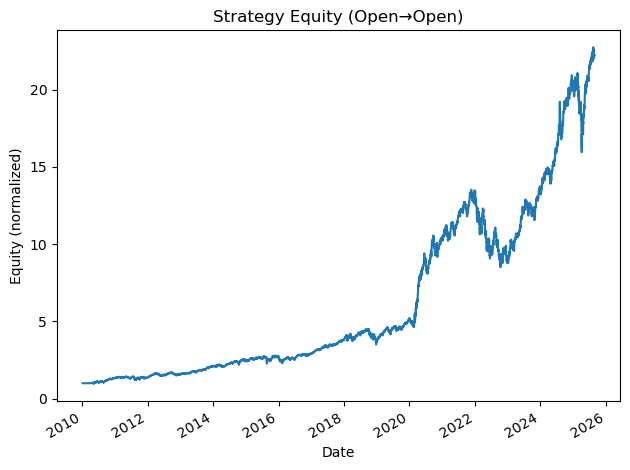

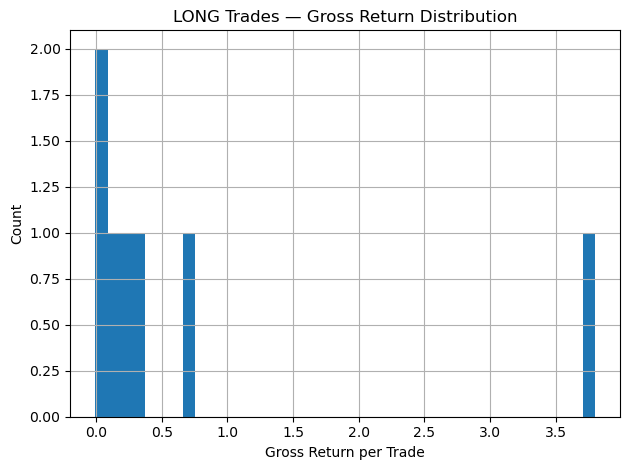

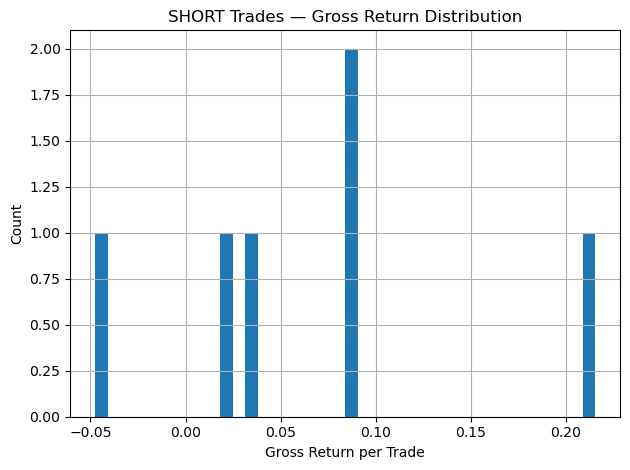

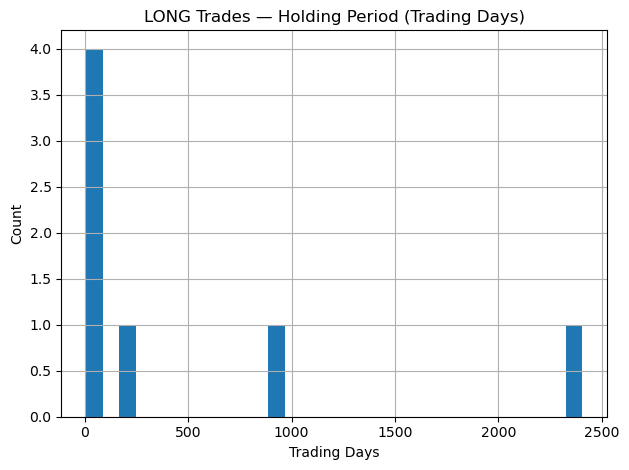

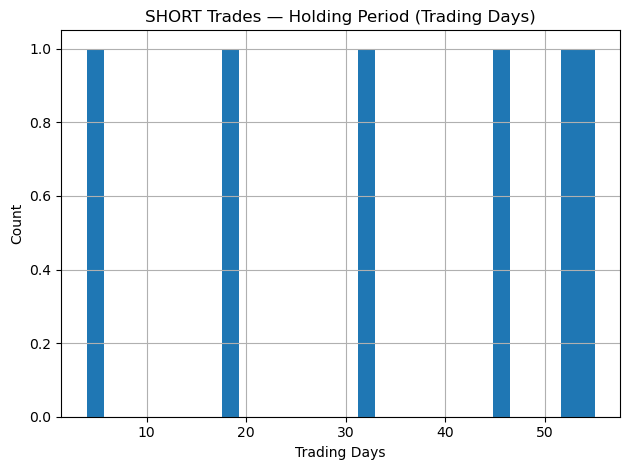

In [8]:
# =========================
# Cell 8 — Plots (Matplotlib)
# =========================
# Equity (normalized)
plt.figure()
(sim['equity'] / sim['equity'].iloc[0]).plot(title="Strategy Equity (Open→Open)")
plt.xlabel("Date")
plt.ylabel("Equity (normalized)")
plt.tight_layout()
plt.show()

# LONG returns histogram
plt.figure()
long_trades['gross_return'].hist(bins=40)
plt.title("LONG Trades — Gross Return Distribution")
plt.xlabel("Gross Return per Trade")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# SHORT returns histogram
plt.figure()
short_trades['gross_return'].hist(bins=40)
plt.title("SHORT Trades — Gross Return Distribution")
plt.xlabel("Gross Return per Trade")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# LONG holding days
plt.figure()
long_trades['hold_trading_days'].hist(bins=30)
plt.title("LONG Trades — Holding Period (Trading Days)")
plt.xlabel("Trading Days")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# SHORT holding days
plt.figure()
short_trades['hold_trading_days'].hist(bins=30)
plt.title("SHORT Trades — Holding Period (Trading Days)")
plt.xlabel("Trading Days")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [22]:
trades


,entry_date,exit_date,direction,entry_open,exit_open,gross_return,hold_trading_days,hold_calendar_days,signal_prev,vix_ratio_prev,sma_prev
0,2010-04-07,2010-04-08,LONG,48.680000,48.490002,-0.003903,1,1,1.310000,0.861465,0.880989
1,2010-05-13,2010-05-14,SHORT,48.410000,47.490002,0.019372,1,1,2.520000,0.957599,0.910854
2,2010-06-09,2010-06-11,LONG,44.500000,44.610001,0.002472,2,2,-1.330000,1.001486,1.006462
3,2010-06-24,2010-06-30,LONG,45.849998,43.230000,-0.057143,4,6,-0.180000,0.919686,0.981478
4,2010-07-02,2010-07-08,LONG,42.660000,44.310001,0.038678,3,6,-1.780000,0.952740,0.972655
5,2010-07-19,2010-07-20,LONG,44.470001,44.000000,-0.010569,1,1,-0.520000,0.857843,0.925675
6,2010-07-22,2010-07-23,LONG,45.270000,45.459999,0.004197,1,1,-0.210000,0.881706,0.909784
7,2010-08-18,2010-08-20,LONG,45.279999,44.790001,-0.010822,2,2,-0.410000,0.851593,0.869211
8,2010-08-23,2010-08-24,LONG,45.200001,43.970001,-0.027212,1,1,-0.720000,0.862898,0.867011
9,2010-08-30,2010-08-31,LONG,43.860001,43.380001,-0.010944,1,1,-0.360000,0.860916,0.871333
